In [23]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('Datasets/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df.drop(columns=['last_review','id','host_id'],inplace=True)

In [12]:
df.neighbourhood_group.nunique()

5

In [15]:
#df.drop(columns=['name'],inplace=True)
df.drop(columns=['host_name'],inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [16]:
df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

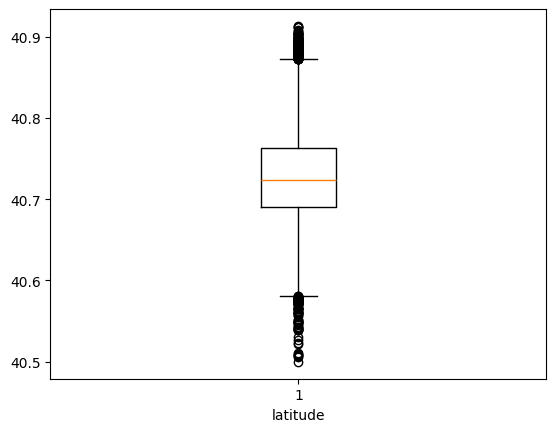

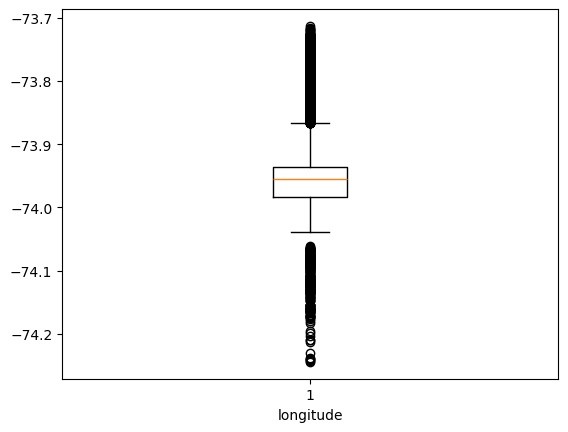

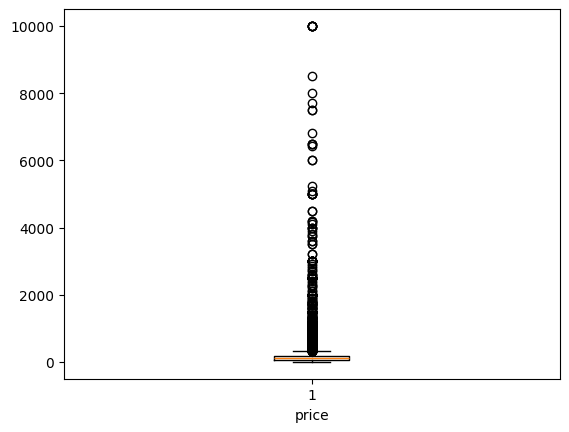

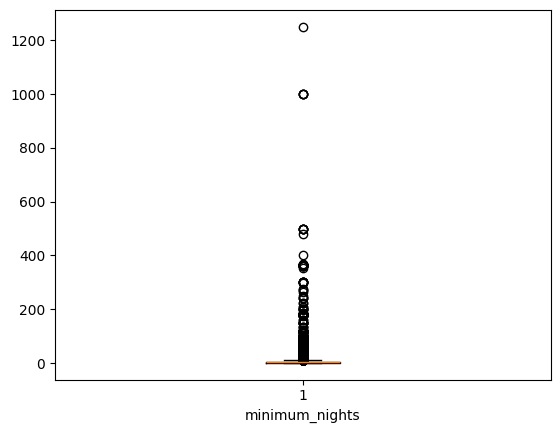

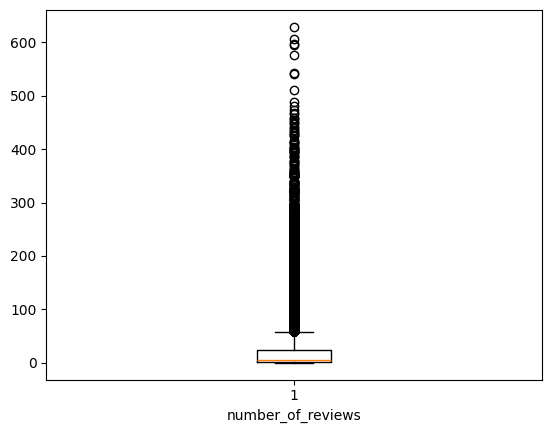

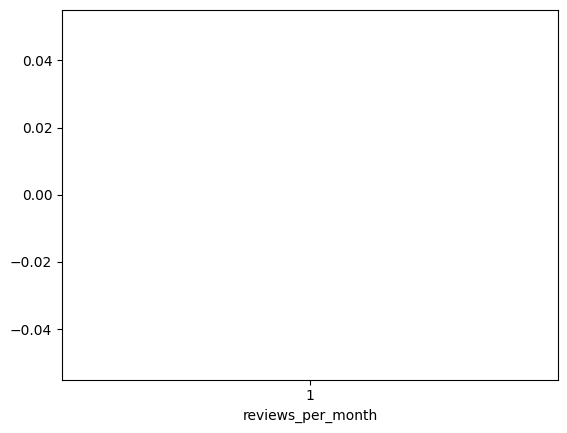

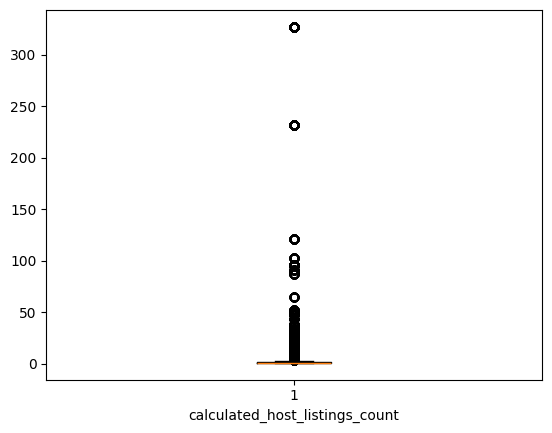

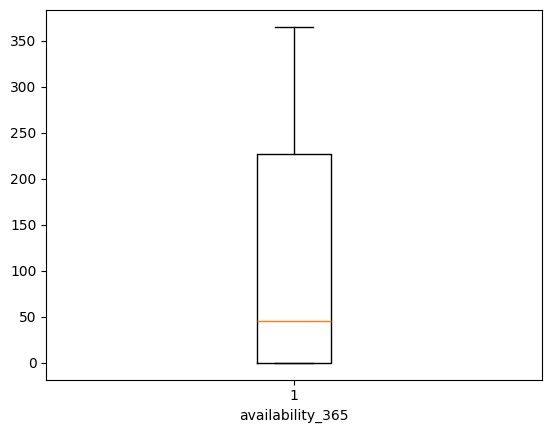

In [28]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        plt.boxplot(df[col])
        plt.xlabel(f'{col}')
        plt.show()

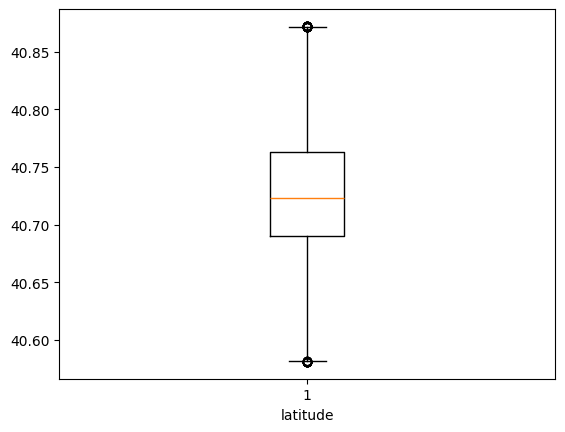

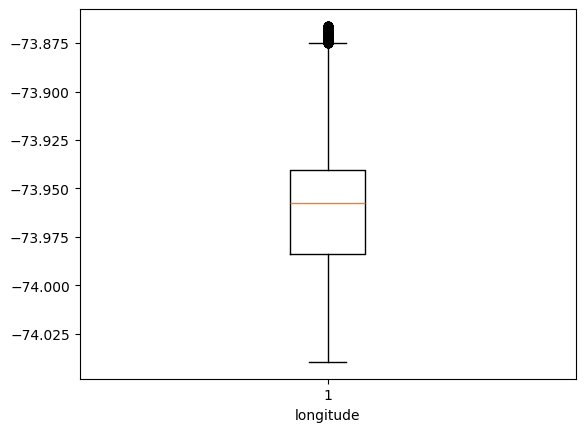

In [45]:
df=drop_outliers('latitude')
df=drop_outliers('longitude')

(46062, 11)

In [59]:
import numpy as np
df['price_log']=np.log(df['price'])
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_3408\2747831630.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_log']=np.log(df['price'])


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.003946
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.416100
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,5.010635
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.488636
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.382027


In [61]:
def drop_outliers(col,df=df):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
    plt.boxplot(df[col])
    plt.xlabel(f'{col}')
    plt.show()
    return df

In [54]:
df = df[df['price'] != 0]

In [56]:
df.price_log.describe()

count    46051.000000
mean         4.749662
std          0.695909
min          2.302585
25%          4.248495
50%          4.700480
75%          5.192957
max          9.210340
Name: price_log, dtype: float64

<Axes: ylabel='Frequency'>

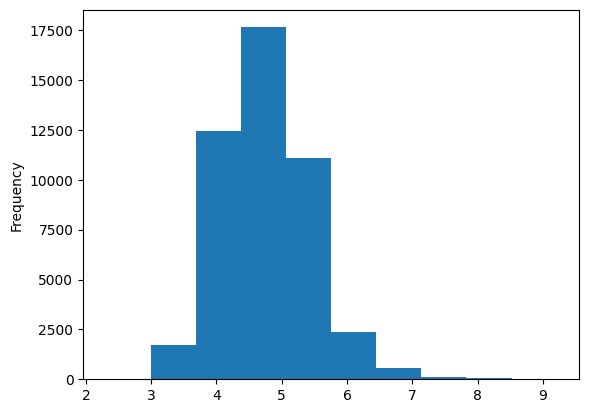

In [57]:
df.price_log.plot(kind='hist')

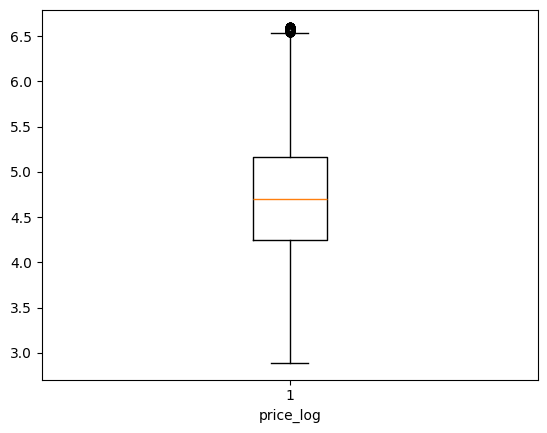

<Axes: ylabel='Frequency'>

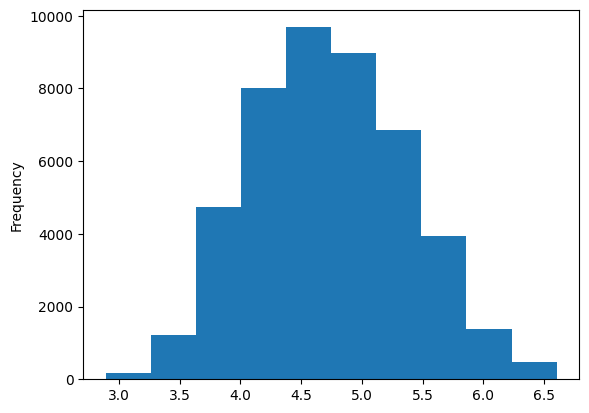

In [62]:
df=drop_outliers('price_log')
df.price_log.plot(kind='hist')

In [64]:
df.shape

(45473, 12)

In [65]:
df.isnull().sum()

neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 9329
calculated_host_listings_count       0
availability_365                     0
price_log                            0
dtype: int64

In [66]:
df['reviews_per_month'].mean()

np.float64(1.3186509517485614)

In [67]:
df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_3408\2682408717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_3408\2682408717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reviews_per_month'].fillna(df['reviews_per_

In [70]:
df.dtypes

neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
price_log                         float64
dtype: object

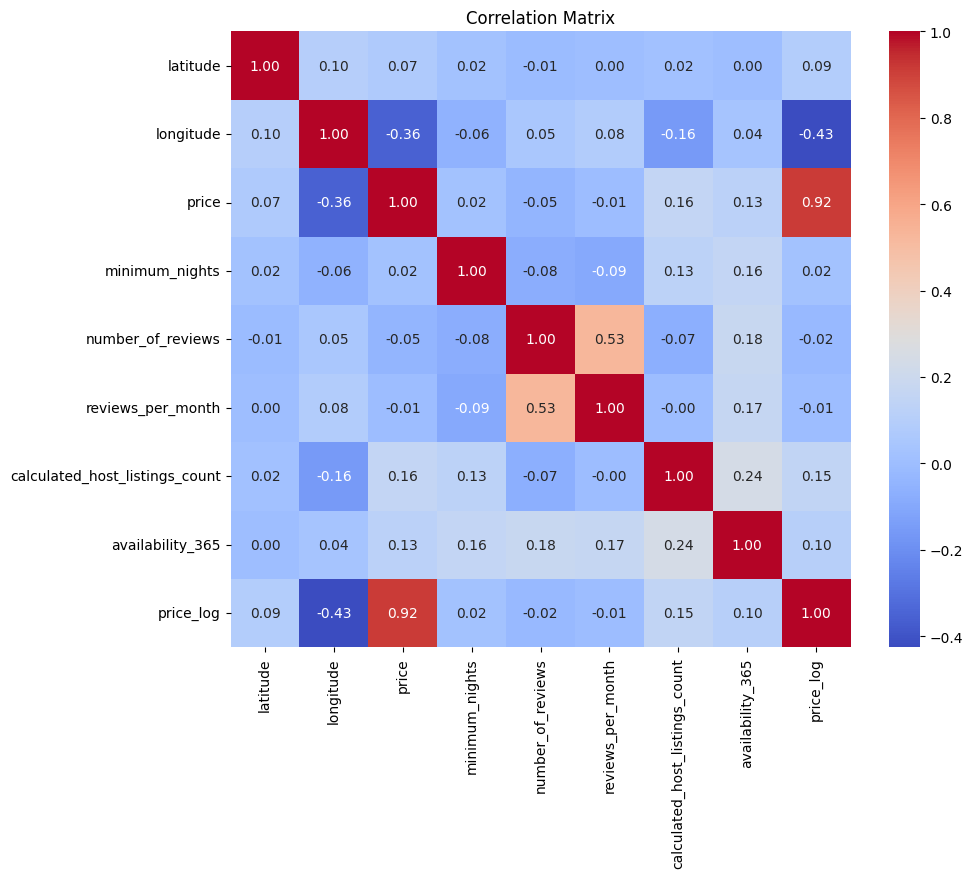

In [75]:
import seaborn as sns
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [73]:
# Automatically encode all object-type (categorical) columns
df_enc = pd.get_dummies(df, drop_first=True)
df_enc=df_enc.astype(int)
df_enc

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log,neighbourhood_group_Brooklyn,...,neighbourhood_Washington Heights,neighbourhood_West Farms,neighbourhood_West Village,neighbourhood_Williamsburg,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40,-73,149,1,9,0,6,365,5,1,...,0,0,0,0,0,0,0,0,1,0
1,40,-73,225,1,45,0,2,355,5,0,...,0,0,0,0,0,0,0,0,0,0
2,40,-73,150,3,0,1,1,365,5,0,...,0,0,0,0,0,0,0,0,1,0
3,40,-73,89,1,270,4,1,194,4,1,...,0,0,0,0,0,0,0,0,0,0
4,40,-73,80,10,9,0,1,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40,-73,70,2,0,1,2,9,4,1,...,0,0,0,0,0,0,0,0,1,0
48891,40,-73,40,4,0,1,2,36,3,1,...,0,0,0,0,0,0,0,0,1,0
48892,40,-73,115,10,0,1,1,27,4,0,...,0,0,0,0,0,0,0,0,0,0
48893,40,-73,55,1,0,1,6,2,4,0,...,0,0,0,0,0,0,0,0,0,1


In [89]:
df_enc.drop(columns=['minimum_nights','number_of_reviews','reviews_per_month'],inplace=True)

In [97]:
df_enc.describe()

,latitude,longitude,price,calculated_host_listings_count,availability_365,price_log,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_Astoria,...,neighbourhood_Washington Heights,neighbourhood_West Farms,neighbourhood_West Village,neighbourhood_Williamsburg,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
count,45473.0,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,...,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000,45473.000000
mean,40.0,-73.068414,139.116003,7.464210,107.676885,4.247795,0.438788,0.466826,0.078750,0.019704,...,0.019704,0.000044,0.016185,0.085765,0.003453,0.000374,0.000154,0.005168,0.452818,0.022959
std,0.0,0.252458,101.041282,34.115721,129.830822,0.714960,0.496244,0.498904,0.269351,0.138983,...,0.138983,0.006632,0.126190,0.280020,0.058658,0.019332,0.012406,0.071703,0.497774,0.149773
min,40.0,-74.000000,18.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.0,-73.000000,70.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.0,-73.000000,110.000000,1.000000,36.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,40.0,-73.000000,175.000000,2.000000,215.000000,5.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,40.0,-73.000000,737.000000,327.000000,365.000000,6.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [94]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare your data
X = df_enc.drop(columns=['price','price_log'])
y = df_enc['price_log']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=4)

# Fit LassoCV
lasso_cv = LassoCV(cv=7, random_state=42)
lasso_cv.fit(X_train, y_train)

# Best alpha found
Best_alpha= lasso_cv.alpha_

# Selected features
selected_features = X.columns[lasso_cv.coef_ != 0]
print("Selected features:", selected_features.tolist())


Selected features: ['calculated_host_listings_count', 'availability_365', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_Astoria', 'neighbourhood_Bath Beach', 'neighbourhood_Battery Park City', 'neighbourhood_Bay Ridge', 'neighbourhood_Belmont', 'neighbourhood_Bensonhurst', 'neighbourhood_Bergen Beach', 'neighbourhood_Boerum Hill', 'neighbourhood_Borough Park', 'neighbourhood_Breezy Point', 'neighbourhood_Brighton Beach', 'neighbourhood_Bronxdale', 'neighbourhood_Brooklyn Heights', 'neighbourhood_Brownsville', 'neighbourhood_Bushwick', 'neighbourhood_Canarsie', 'neighbourhood_Carroll Gardens', 'neighbourhood_Chelsea', 'neighbourhood_Chinatown', 'neighbourhood_Civic Center', 'neighbourhood_Claremont Village', 'neighbourhood_Clinton Hill', 'neighbourhood_Cobble Hill', 'neighbourhood_Columbia St', 'neighbourhood_Concourse', 'neighbourhood_Concourse Village', 'neighbourhood_Coney Island', 'neighbourhood_Corona', 'neighbourhood_Crown Heights', 'neighbourhood_C

In [101]:
from sklearn.linear_model import Lasso
model=Lasso(alpha=Best_alpha,max_iter=100,tol=0.1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
model.score(X_test,y_test)

0.47556120948228775

In [102]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))


R²: 0.47556120948228775
MAE: 0.4195134514283101
RMSE: 0.2752081163092009


In [98]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
model.score(X_test,y_test)

0.442448032161717